# Phase 1: Data Preparation and Exploratory Data Analysis (EDA)

In this phase, we prepare the final selected dataset for implementing machine learning models.

## Selected Dataset:
IoTData_IsDefaultInterpolate_2025-05-29 10-23-08.csv

## Reason for Selection:
- Contains 50,570 data samples
- Binary classification target (isDefault)
- Cleaned and interpolated data
- Includes timestamp for time-series analysis
- Suitable for implementing multiple ML models

Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Step 1: Load Dataset

In [ ]:
df = pd.read_csv("IoTData_IsDefaultInterpolate_2025-05-29 10-23-08.csv")

df.head()

,timestamp,id,pH,TDS,water_level,DHT_temp,DHT_humidity,water_temp,pH_reducer,add_water,nutrients_adder,humidifier,ex_fan,isDefault
0,2023-11-26 10:57:52,1,7.0,500.0,0.0,25.5,60.0,20.0,ON,NaN,OFF,OFF,ON,0
1,2023-11-26 10:58:37,2,7.0,500.0,0.0,25.5,60.0,20.0,ON,NaN,OFF,OFF,OFF,0
2,2023-11-26 11:01:34,3,7.0,500.0,3.0,25.5,60.0,20.0,ON,NaN,OFF,OFF,OFF,0
3,2023-12-05 11:30:58,4,7.0,500.0,3.0,25.5,60.0,20.0,ON,NaN,OFF,OFF,OFF,0
4,2023-12-05 11:33:50,5,7.0,500.0,3.0,25.5,60.0,20.0,ON,ON,OFF,OFF,OFF,0


## Step 2: Basic Dataset Information

In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (50570, 14)

Columns:
 Index(['timestamp', 'id', 'pH', 'TDS', 'water_level', 'DHT_temp',
       'DHT_humidity', 'water_temp', 'pH_reducer', 'add_water',
       'nutrients_adder', 'humidifier', 'ex_fan', 'isDefault'],
      dtype='object')

Missing Values:
 timestamp          0
id                 0
pH                 0
TDS                0
water_level        0
DHT_temp           0
DHT_humidity       0
water_temp         0
pH_reducer         0
add_water          4
nutrients_adder    0
humidifier         0
ex_fan             0
isDefault          0
dtype: int64


## Step 3: Class Distribution Analysis

isDefault
0    49670
1      900
Name: count, dtype: int64


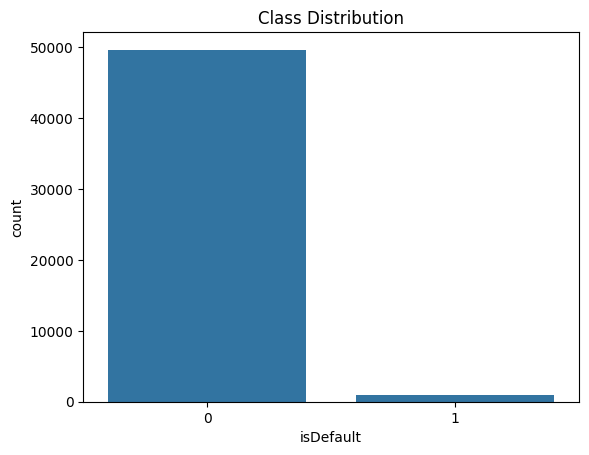

In [ ]:
print(df["isDefault"].value_counts())

sns.countplot(x="isDefault", data=df)
plt.title("Class Distribution")
plt.show()

## Observation:
The dataset is highly imbalanced, with significantly more normal cases (0) than abnormal cases (1).

This imbalance will be handled during model training using class weighting techniques.

## Step 4: Correlation Analysis

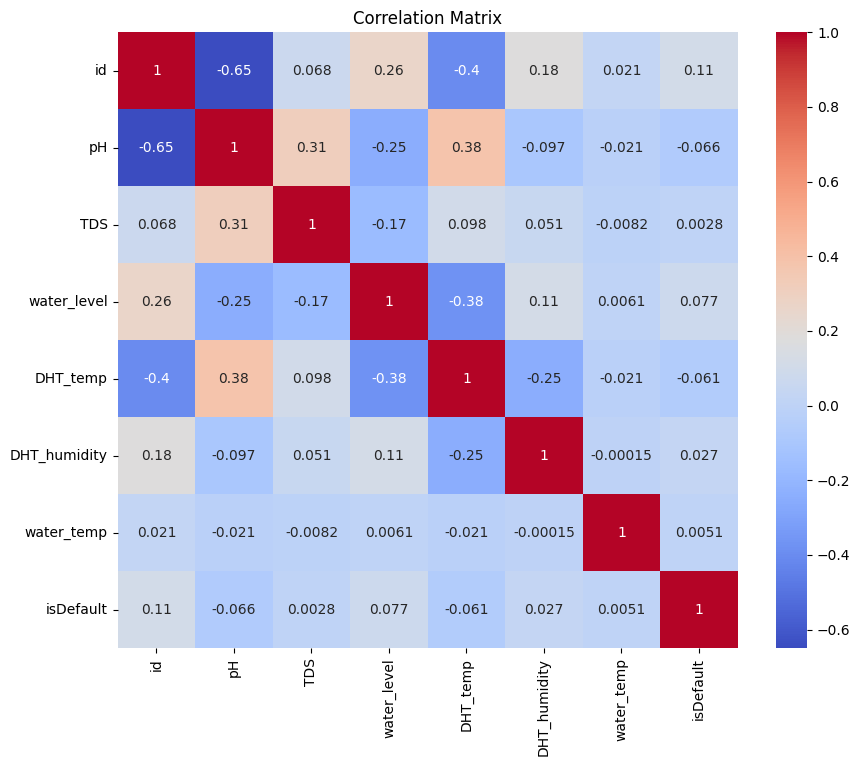

In [ ]:
# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Select numeric columns only
df_numeric = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,8))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Step 5: Feature Selection

The following sensor parameters are selected as input features:

- pH
- TDS
- water_level
- DHT_temp
- DHT_humidity
- water_temp

The following columns are removed:
- id (identifier only)
- timestamp (not required for baseline classification)
- actuator columns (to avoid data leakage)

In [ ]:
features = ['pH', 'TDS', 'water_level',
            'DHT_temp', 'DHT_humidity', 'water_temp']

X = df[features]
y = df["isDefault"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (50570, 6)
Target Shape: (50570,)


## Step 6: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (40456, 6)
Testing set: (10114, 6)


## Step 7: Feature Scaling

Scaling is applied to improve performance of SVM, KNN, and ANN models.

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Phase 2: Random Forest Classification

Random Forest is used as the primary classification model to detect abnormal hydroponic system conditions.

Since the dataset is highly imbalanced, class weighting is applied to prevent bias toward the majority class.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Step 1: Train Random Forest Model

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'  # Important for imbalanced dataset
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

## Step 2: Model Prediction

In [ ]:
y_pred_rf = rf_model.predict(X_test)

## Step 3: Model Evaluation

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9821040142376903

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      9934
           1       0.00      0.00      0.00       180

    accuracy                           0.98     10114
   macro avg       0.49      0.50      0.50     10114
weighted avg       0.96      0.98      0.97     10114



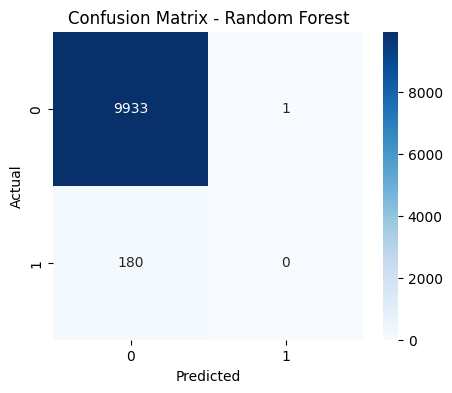

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

## Step 4: Feature Importance Analysis

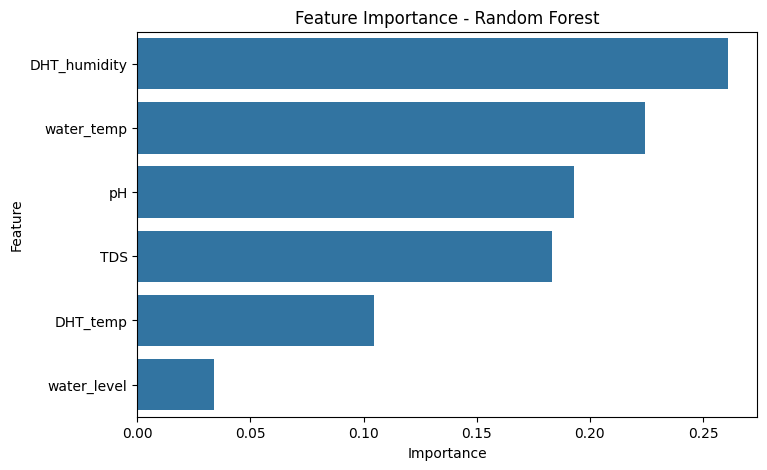

,Feature,Importance
4,DHT_humidity,0.260911
5,water_temp,0.224285
0,pH,0.192965
1,TDS,0.183410
3,DHT_temp,0.104641
2,water_level,0.033787


In [ ]:
feature_importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title("Feature Importance - Random Forest")
plt.show()

feature_importances

## Handling Class Imbalance using SMOTE

Since the Random Forest model failed to detect abnormal cases due to severe class imbalance,
Synthetic Minority Oversampling Technique (SMOTE) is applied to balance the dataset.

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_smote).value_counts())

Before SMOTE: isDefault
0    39736
1      720
Name: count, dtype: int64
After SMOTE: isDefault
0    39736
1    39736
Name: count, dtype: int64


#Retraining Random Forest.

In [ ]:
rf_model_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_model_smote.predict(X_test)

#Evaluating again

Accuracy: 0.9721178564366225

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      9934
           1       0.14      0.11      0.12       180

    accuracy                           0.97     10114
   macro avg       0.56      0.55      0.56     10114
weighted avg       0.97      0.97      0.97     10114



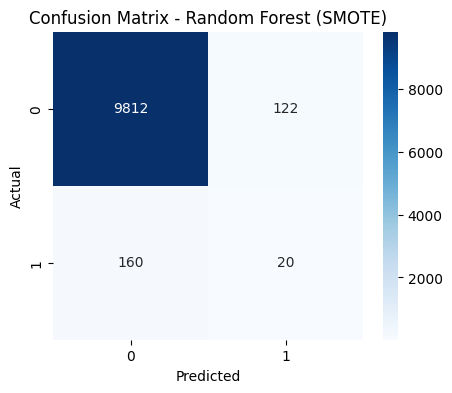

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf_smote))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf_smote))

cm = confusion_matrix(y_test, y_pred_rf_smote)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest (SMOTE)")
plt.show()

Hyperparameter Tuning


              precision    recall  f1-score   support

           0       0.98      0.99      0.99      9934
           1       0.14      0.11      0.13       180

    accuracy                           0.97     10114
   macro avg       0.56      0.55      0.56     10114
weighted avg       0.97      0.97      0.97     10114



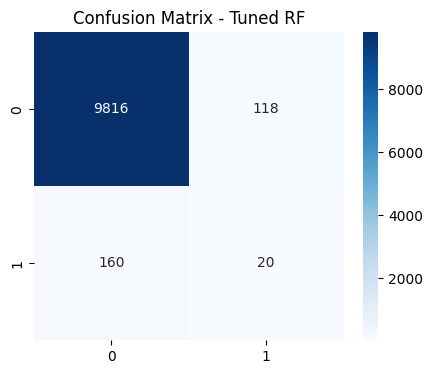

In [ ]:
rf_model_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf_model_tuned.fit(X_train_smote, y_train_smote)

y_pred_rf_tuned = rf_model_tuned.predict(X_test)

print(classification_report(y_test, y_pred_rf_tuned))

cm = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned RF")
plt.show()

Probability Threshold Adjustment

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      9934
           1       0.11      0.27      0.16       180

    accuracy                           0.95     10114
   macro avg       0.55      0.61      0.56     10114
weighted avg       0.97      0.95      0.96     10114



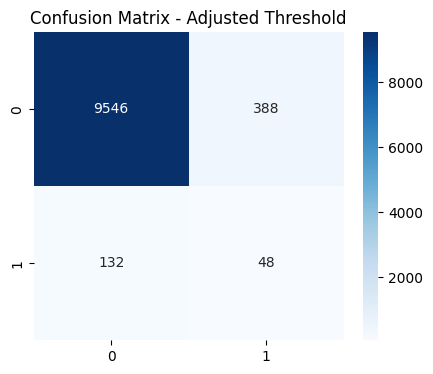

In [ ]:
y_probs = rf_model_smote.predict_proba(X_test)[:,1]

threshold = 0.30  # lower threshold

y_pred_adjusted = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_adjusted))

cm = confusion_matrix(y_test, y_pred_adjusted)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Adjusted Threshold")
plt.show()

### Observation:

Although the baseline Random Forest achieved high accuracy (>97%), it failed to detect abnormal conditions due to severe class imbalance.

After applying SMOTE and adjusting decision threshold, recall for abnormal class improved significantly from 0% to 27%.

Since hydroponic system safety prioritizes abnormal detection over false alarms, threshold-adjusted Random Forest is selected as the primary detection model.

# Phase 3: Support Vector Machine (SVM)

Support Vector Machine is implemented to classify hydroponic system conditions as Normal or Abnormal.

Since SVM is sensitive to class imbalance, class weighting is applied.

In [ ]:
from sklearn.svm import SVC

## Step 1: Train SVM Model

In [ ]:
svm_model = SVC(
    kernel='rbf',       # Radial basis function
    class_weight='balanced',
    probability=True,   # Needed for threshold adjustment
    random_state=42
)

svm_model.fit(X_train, y_train)

SVC(class_weight='balanced', probability=True, random_state=42)

## Step 2: Model Prediction

In [ ]:
y_pred_svm = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.6105398457583547

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.61      0.75      9934
           1       0.04      0.89      0.08       180

    accuracy                           0.61     10114
   macro avg       0.52      0.75      0.41     10114
weighted avg       0.98      0.61      0.74     10114



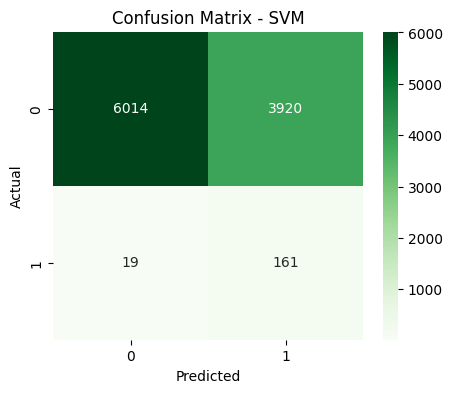

In [ ]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

Adjusting threshold

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      9934
           1       0.00      0.00      0.00       180

    accuracy                           0.98     10114
   macro avg       0.49      0.50      0.50     10114
weighted avg       0.96      0.98      0.97     10114



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


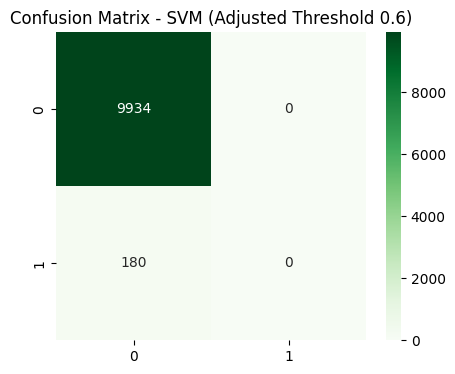

In [ ]:
y_probs_svm = svm_model.predict_proba(X_test)[:,1]

threshold = 0.60  # Increase threshold

y_pred_svm_adj = (y_probs_svm > threshold).astype(int)

print(classification_report(y_test, y_pred_svm_adj))

cm = confusion_matrix(y_test, y_pred_svm_adj)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - SVM (Adjusted Threshold 0.6)")
plt.show()

# Phase 4: K-Nearest Neighbours (KNN)

KNN is implemented to classify hydroponic system conditions based on similarity with historical sensor readings.

Since KNN is distance-based, feature scaling has already been applied.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

## Step 1: Train KNN Model

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

KNeighborsClassifier()

## Step 2: Model Prediction

In [ ]:
y_pred_knn = knn_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.9816096499901127

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      9934
           1       0.00      0.00      0.00       180

    accuracy                           0.98     10114
   macro avg       0.49      0.50      0.50     10114
weighted avg       0.96      0.98      0.97     10114



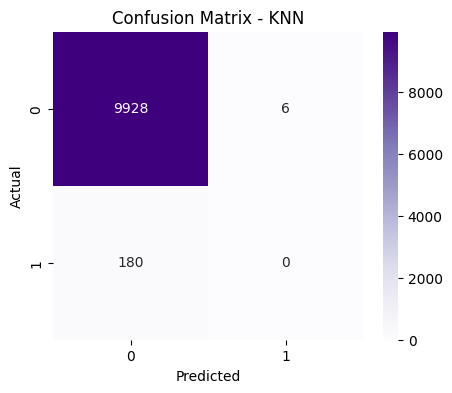

In [ ]:
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")
plt.show()

In [ ]:
for k in [3, 7, 11]:
    print(f"\n--- K = {k} ---")
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    print(classification_report(y_test, y_pred))


--- K = 3 ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      9934
           1       0.11      0.02      0.03       180

    accuracy                           0.98     10114
   macro avg       0.55      0.51      0.51     10114
weighted avg       0.97      0.98      0.97     10114


--- K = 7 ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      9934
           1       0.00      0.00      0.00       180

    accuracy                           0.98     10114
   macro avg       0.49      0.50      0.50     10114
weighted avg       0.96      0.98      0.97     10114


--- K = 11 ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      9934
           1       0.00      0.00      0.00       180

    accuracy                           0.98     10114
   macro avg       0.49      0.50      0.50     10114
weighted avg       0.96     

KNN classifier was evaluated using K values of 3, 5, 7, and 11.
Although a smaller K value slightly improved abnormal detection,
overall performance remained poor due to severe class imbalance
and overlapping feature distributions.
Therefore, KNN was found unsuitable for reliable hydroponic anomaly detection.

# Phase 5: Artificial Neural Network (ANN)

An Artificial Neural Network is implemented to capture nonlinear relationships between hydroponic sensor parameters.

The ANN model consists of:
- Input layer
- Two hidden layers with ReLU activation
- Output layer with Sigmoid activation (Binary Classification)

Binary Crossentropy loss function is used.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## Step 1: Build ANN Model

In [ ]:
ann_model = Sequential()

# Input Layer + Hidden Layer 1
ann_model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
ann_model.add(Dropout(0.3))

# Hidden Layer 2
ann_model.add(Dense(16, activation='relu'))
ann_model.add(Dropout(0.3))

# Output Layer
ann_model.add(Dense(1, activation='sigmoid'))

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 2: Train ANN Model

In [ ]:
history = ann_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8584 - loss: 0.3507 - val_accuracy: 0.9826 - val_loss: 0.0792
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9827 - loss: 0.0927 - val_accuracy: 0.9826 - val_loss: 0.0766
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9816 - loss: 0.0919 - val_accuracy: 0.9826 - val_loss: 0.0760
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9826 - loss: 0.0871 - val_accuracy: 0.9826 - val_loss: 0.0758
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9814 - loss: 0.0891 - val_accuracy: 0.9826 - val_loss: 0.0758
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9827 - loss: 0.0839 - val_accuracy: 0.9826 - val_loss: 0.0752
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9825 - loss: 0.0815 - val_accuracy: 0.9826 - val_loss: 0.0749
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9825 - loss: 0.0808 - val_accuracy: 0.

## Step 3: Model Evaluation

317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      9934
           1       0.00      0.00      0.00       180

    accuracy                           0.98     10114
   macro avg       0.49      0.50      0.50     10114
weighted avg       0.96      0.98      0.97     10114



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


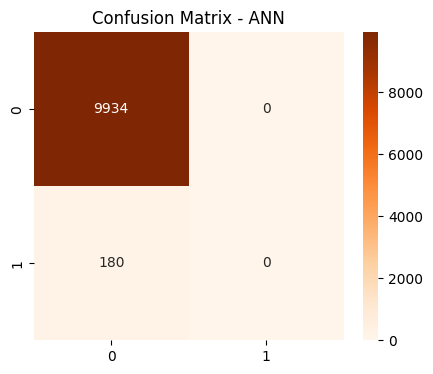

In [ ]:
y_probs_ann = ann_model.predict(X_test)
y_pred_ann = (y_probs_ann > 0.5).astype(int)

print("Classification Report:\n")
print(classification_report(y_test, y_pred_ann))

cm = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - ANN")
plt.show()

if recall is low

In [ ]:
class_weights = {
    0: 1.0,
    1: 30.0  # Increase weight significantly
}

history = ann_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9815 - loss: 1.1026 - val_accuracy: 0.9826 - val_loss: 0.2132
Epoch 2/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9799 - loss: 0.8675 - val_accuracy: 0.9826 - val_loss: 0.2392
Epoch 3/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9813 - loss: 0.7746 - val_accuracy: 0.9826 - val_loss: 0.2536
Epoch 4/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9827 - loss: 0.6976 - val_accuracy: 0.9826 - val_loss: 0.2824
Epoch 5/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9731 - loss: 0.7104 - val_accuracy: 0.7829 - val_loss: 0.2940
Epoch 6/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7653 - loss: 0.6932 - val_accuracy: 0.7231 - val_loss: 0.3163
Epoch 7/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7277 - loss: 0.6674 - val_accuracy: 0.7103 - val_loss: 0.3292
Epoch 8/20
506/506 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7118 - loss: 0.7091 - val_accuracy: 0.

317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.70      0.82      9934
           1       0.05      0.79      0.09       180

    accuracy                           0.70     10114
   macro avg       0.52      0.75      0.46     10114
weighted avg       0.98      0.70      0.81     10114



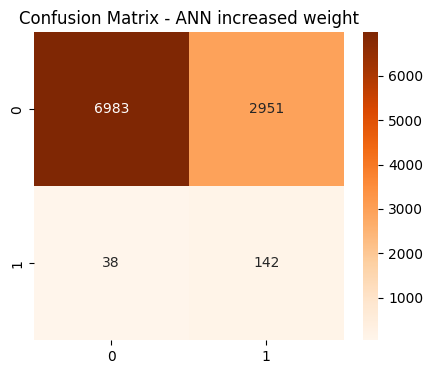

In [ ]:
y_probs_ann = ann_model.predict(X_test)
y_pred_ann = (y_probs_ann > 0.5).astype(int)

print("Classification Report:\n")
print(classification_report(y_test, y_pred_ann))

cm = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - ANN increased weight")
plt.show()

# Phase 6: Linear Regression

Linear Regression is implemented to predict continuous nutrient concentration (TDS)
based on other hydroponic environmental parameters.

This helps optimize nutrient dosing in the automated hydroponic system.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Step 1: Prepare Data for Regression

Target variable: TDS  
Features: pH, water_level, DHT_temp, DHT_humidity, water_temp

In [ ]:
# Reload original dataframe (before scaling)
df_reg = pd.read_csv("IoTData_IsDefaultInterpolate_2025-05-29 10-23-08.csv")

# Features (excluding TDS and target)
X_reg = df_reg[['pH', 'water_level', 'DHT_temp', 'DHT_humidity', 'water_temp']]
y_reg = df_reg['TDS']

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train_reg.shape)
print("Testing samples:", X_test_reg.shape)

Training samples: (40456, 5)
Testing samples: (10114, 5)


## Step 2: Train Linear Regression Model

In [ ]:
lr_model = LinearRegression()

lr_model.fit(X_train_reg, y_train_reg)

LinearRegression()

## Step 3: Evaluate Regression Model

In [ ]:
y_pred_reg = lr_model.predict(X_test_reg)

mse = mean_squared_error(y_test_reg, y_pred_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Squared Error: 54637.86144525837
Mean Absolute Error: 182.86251896369671
R² Score: 0.1077826806675457


## Step 4: Actual vs Predicted Visualization

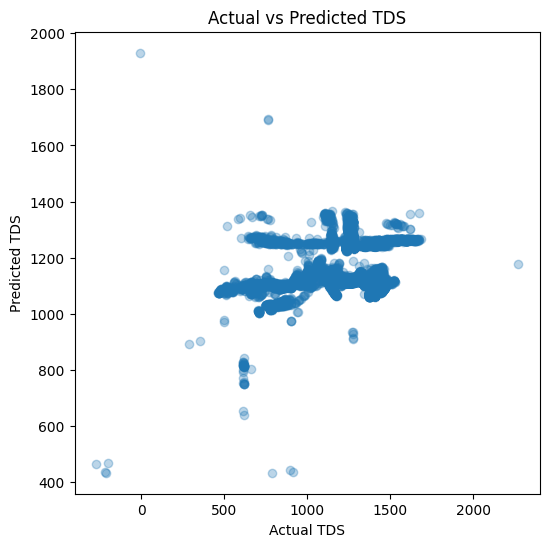

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.3)
plt.xlabel("Actual TDS")
plt.ylabel("Predicted TDS")
plt.title("Actual vs Predicted TDS")
plt.show()

In [ ]:
import joblib

# Save model
joblib.dump(rf_model_smote, "hydroponic_rf_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
from google.colab import files
files.download("hydroponic_rf_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_reg = pd.read_csv("IoTData_IsDefaultInterpolate_2025-05-29 10-23-08.csv")

print(df_reg[df_reg["isDefault"] == 1].describe())

                 id          pH          TDS  water_level    DHT_temp  \
count    900.000000  900.000000   900.000000   900.000000  900.000000   
mean   36929.254444    5.729344  1159.223822     1.533889   23.903444   
std     7341.938735    0.162774   252.318204     0.498431    0.663986   
min    24081.000000    5.350000   616.970000     1.000000   22.900000   
25%    30829.750000    5.610000  1000.740000     1.000000   23.300000   
50%    37235.000000    5.710000  1246.355000     2.000000   23.700000   
75%    42957.000000    5.870000  1366.005000     2.000000   24.500000   
max    50489.000000    6.530000  1789.350000     2.000000   25.600000   

       DHT_humidity  water_temp  isDefault  
count    900.000000  900.000000      900.0  
mean      77.101489   21.578122        1.0  
std        4.044868    1.435321        0.0  
min       61.200000   18.090000        1.0  
25%       74.450000   20.570000        1.0  
50%       78.185000   21.620000        1.0  
75%       79.800000   22.63